# Framework de Evaluación por Fuentes de Datos

Este notebook evalúa el rendimiento de los modelos frente a diferentes subconjuntos de datos (por fuentes) excluyendo variables que puedan presentar Data Leakage (como puntajes consolidados) para asegurar un análisis insesgado.

In [6]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Setup y Extracción del Hold-out

Extraemos un set de prueba virgen, eliminando las columnas que generan sesgo (Data Leakage).

In [7]:
# Cargar datos originales para obtener un Test Set realista
df_raw = pd.read_csv('raw_data/dataset_sintetico_biocatch_vishing.csv')

# Excluir explícitamente features que causan data leakage y scores simulados según requerimiento
leakage_cols = [
    'session_id', 'customer_id', 'session_timestamp', 
    'biocatch_risk_score', 'biocatch_genuine_score', 
    'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 
    'biocatch_bot_indicator', 'days_to_claim', 'claim_category'
]

df_raw = df_raw.drop(columns=[c for c in leakage_cols if c in df_raw.columns])

# Separar el Hold-out (Set de Prueba)
X_orig = df_raw.drop(columns=['is_vishing'])
y_orig = df_raw['is_vishing']

_, X_test_full, _, y_test_full = train_test_split(X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig)

## 2. Definición del Subconjunto de Características (Feature Sets)

In [11]:
# Grupo 1: Datos Exclusivos de Biocatch
biocatch_features = [
    
    # ---- DATOS KEYSTROKE DYNAMICS ----
    'avg_keyhold_ms',
    'avg_interkey_latency_ms',
    'typing_speed_cps',
    'keystroke_variability',
    'segmented_typing_ratio',
    
    # ---- TOUCH DYNAMICS ----
    'avg_touch_pressure',
    'avg_touch_size_px',
    'swipe_speed_px_s',
    'swipe_directional_variance',
    'scroll_speed_avg',
    
    # ---- Sensores dispositivo ---- 
    'device_tilt_angle_mean',
    'device_tilt_variability',
    'gyro_rotation_rate_mean',
    'accelerometer_jerk_mean',
    'phone_motion_events',
    
    # ---- Señales cognitivas - Hesitacion -----
    'hesitation_count',
    'avg_hesitation_duration_s',
    'max_hesitation_duration_s',
    
    # ---- Señales cognitivas - Dead time ----
    'dead_time_periods',
    'total_dead_time_s',
    'dead_time_ratio',
    
    # ---- Señales cognitivas - Errores y correcciones ----
    'input_error_count',
    'input_correction_count',
    'amount_field_corrections',
    'beneficiary_field_corrections',
    'copy_paste_events',
    
    # ---- Señales cognitivas - Familiaridad y Doodling ----
    'data_familiarity_score',
    'doodling_events',
    'hour_of_day',
    'is_atypical_hour',
    'phone_call_active',
    'call_overlap_duration_s',
    'remote_access_tool_detected',
    'suspicious_app_detected'
]

# Garantizar que ninguna variable de leakage esté en la lista por error
biocatch_features = [f for f in biocatch_features if f not in leakage_cols]
print(f"Total features en el subconjunto Biocatch (limpias): {len(biocatch_features)}")

Total features en el subconjunto Biocatch (limpias): 34


## 3. Función Evaluadora de Subconjuntos (Framework Pipeline)

In [12]:
def evaluate_feature_subset(feature_list, subset_name="Subset"):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(eval_metric='logloss', max_depth=6, learning_rate=0.1, random_state=42),
        'Deep Learning (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42)
    }

    data_paths = glob.glob('data/**/*.csv', recursive=True)
    results = []
    
    # Filtrar el test set
    X_test_sub = X_test_full[[c for c in feature_list if c in X_test_full.columns]]
    
    # One-Hot Encoding para datos categóricos si existen (e.g. device_type, os_type)
    cat_cols_present = [c for c in ['device_type', 'os_type'] if c in X_test_sub.columns]
    if cat_cols_present:
        X_test_sub = pd.get_dummies(X_test_sub, columns=cat_cols_present, drop_first=True)

    print(f"Iniciando evaluación iterativa masiva para: {subset_name}...")

    for path in data_paths:
        technique = Path(path).parent.name
        ratio = Path(path).stem
        
        df_train = pd.read_csv(path)
        
        y_train = df_train['is_vishing']
        X_train_sub = df_train[[c for c in feature_list if c in df_train.columns]]
        
        if cat_cols_present:
            X_train_sub = pd.get_dummies(X_train_sub, columns=cat_cols_present, drop_first=True)
        
        # Asegurar paridad entre features de entreno y prueba
        X_train_sub, X_test_sub_aligned = X_train_sub.align(X_test_sub, join='inner', axis=1)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_sub)
        X_test_scaled = scaler.transform(X_test_sub_aligned)
        
        for model_name, model in models.items():
            if model_name in ['Logistic Regression', 'Deep Learning (MLP)']:
                X_tr, X_te = X_train_scaled, X_test_scaled
            else:
                X_tr, X_te = X_train_sub, X_test_sub_aligned
                
            model.fit(X_tr, y_train)
            
            y_pred = model.predict(X_te)
            y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred
            
            recall = recall_score(y_test_full, y_pred)
            precision = precision_score(y_test_full, y_pred, zero_division=0)
            f1 = f1_score(y_test_full, y_pred, zero_division=0)
            roc_auc = roc_auc_score(y_test_full, y_prob)
            pr_auc = average_precision_score(y_test_full, y_prob)
            
            results.append({
                'Feature_Set': subset_name,
                'Technique': technique,
                'Ratio_%': ratio,
                'Model': model_name,
                'Recall': recall,
                'Precision': precision,
                'F1': f1,
                'ROC_AUC': roc_auc,
                'PR_AUC': pr_auc
            })
            
    print("¡Evaluación finalizada!\n")
    return pd.DataFrame(results)

## 4. Analisis Fuente Exclusiva: Biocatch

In [13]:
df_biocatch_results = evaluate_feature_subset(biocatch_features, subset_name="Biocatch Data")

# Visualizar tabla liderada
df_biocatch_sorted = df_biocatch_results.sort_values(by='PR_AUC', ascending=False)
display(df_biocatch_sorted.head(15).style.background_gradient(cmap='viridis', subset=['Recall', 'PR_AUC', 'ROC_AUC']))

Iniciando evaluación iterativa masiva para: Biocatch Data...
¡Evaluación finalizada!



,Feature_Set,Technique,Ratio_%,Model,Recall,Precision,F1,ROC_AUC,PR_AUC
13,Biocatch Data,random_oversampling,10,Random Forest,0.010000,1.000000,0.019802,1.000000,1.000000
17,Biocatch Data,random_oversampling,20,Random Forest,0.034000,1.000000,0.065764,1.000000,1.000000
21,Biocatch Data,random_oversampling,25,Random Forest,0.130000,1.000000,0.230088,1.000000,1.000000
9,Biocatch Data,borderline_smote,25,Random Forest,0.016000,1.000000,0.031496,1.000000,0.999996
41,Biocatch Data,smote_undersampling,20,Random Forest,0.000000,0.000000,0.000000,0.999998,0.999960
5,Biocatch Data,borderline_smote,20,Random Forest,0.000000,0.000000,0.000000,0.999994,0.999885
25,Biocatch Data,smote,10,Random Forest,0.002000,1.000000,0.003992,0.999979,0.999545
1,Biocatch Data,borderline_smote,10,Random Forest,0.000000,0.000000,0.000000,0.999967,0.999237
29,Biocatch Data,smote,20,Random Forest,0.000000,0.000000,0.000000,0.999950,0.998720
37,Biocatch Data,smote_undersampling,10,Random Forest,0.000000,0.000000,0.000000,0.999945,0.998547


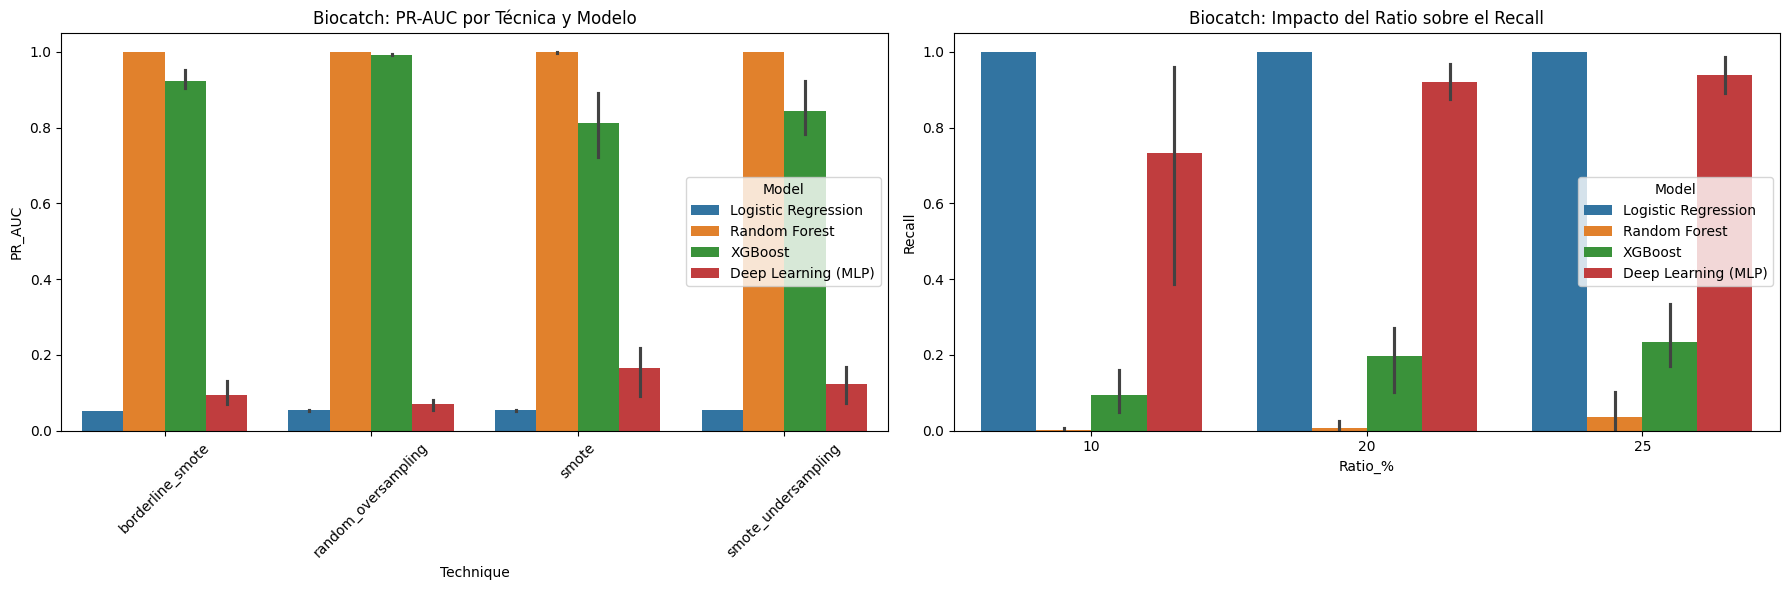

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_biocatch_results, x='Technique', y='PR_AUC', hue='Model', ax=ax1)
ax1.set_title('Biocatch: PR-AUC por Técnica y Modelo')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sns.barplot(data=df_biocatch_results, x='Ratio_%', y='Recall', hue='Model', ax=ax2)
ax2.set_title('Biocatch: Impacto del Ratio sobre el Recall')

plt.tight_layout()
plt.show()